# Predictive Analytics Using Historical Data

## Sales Forecast Prediction Using Walmart Historical Sales Data

### Objective

Build a machine learning model to predict future weekly sales using historical Walmart sales data.

### Tools Used

- Google Colab
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

### Author

Your Name

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import pandas as pd

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving train.csv to train (2).csv


In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
df.shape

(9800, 18)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df = df.sort_values('Order Date')

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
7980,7981,CA-2015-103800,2015-01-03,07/01/2015,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095.0,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448
741,742,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540
740,741,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736
739,740,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784
1759,1760,CA-2015-141817,2015-01-05,12/01/2015,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143.0,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536


In [ ]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()

In [ ]:
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

In [ ]:
monthly_sales.head()

,Order Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [ ]:
monthly_sales['Month'] = range(len(monthly_sales))
monthly_sales.head()

,Order Date,Sales,Month
0,2015-01-01,14205.707,0
1,2015-02-01,4519.892,1
2,2015-03-01,55205.797,2
3,2015-04-01,27906.855,3
4,2015-05-01,23644.303,4


In [ ]:
X = monthly_sales[['Month']]
y = monthly_sales['Sales']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': predictions
})

comparison.head()

,Actual Sales,Predicted Sales
0,38679.7670,54632.289729
1,43825.9822,67294.355937
2,51165.0590,53658.284636
3,62837.8480,70216.371215
4,18542.4910,51710.274450


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R2 Score:", r2_score(y_test, predictions))

Mean Absolute Error: 19718.02686817492
Root Mean Squared Error: 23410.539833636285
R2 Score: -1.5242689676740677


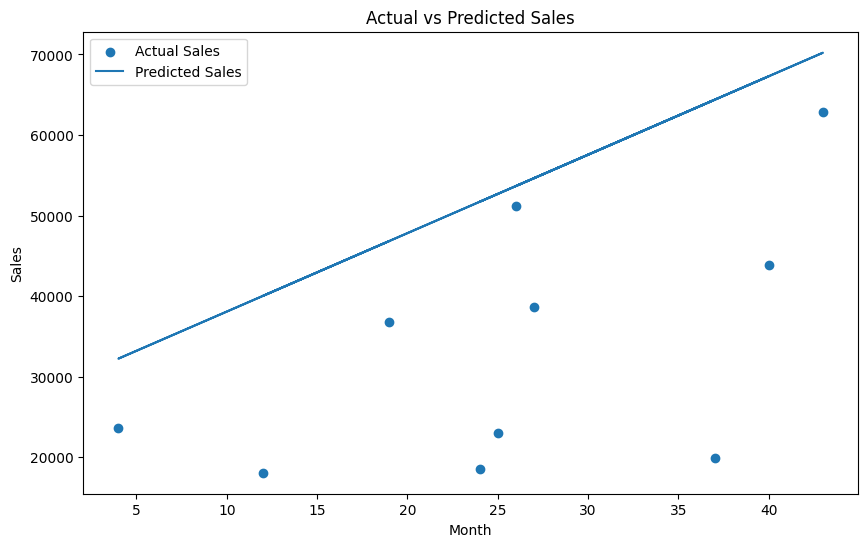

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(X_test, y_test, label='Actual Sales')

plt.plot(X_test, predictions, label='Predicted Sales')

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")

plt.legend()

plt.show()

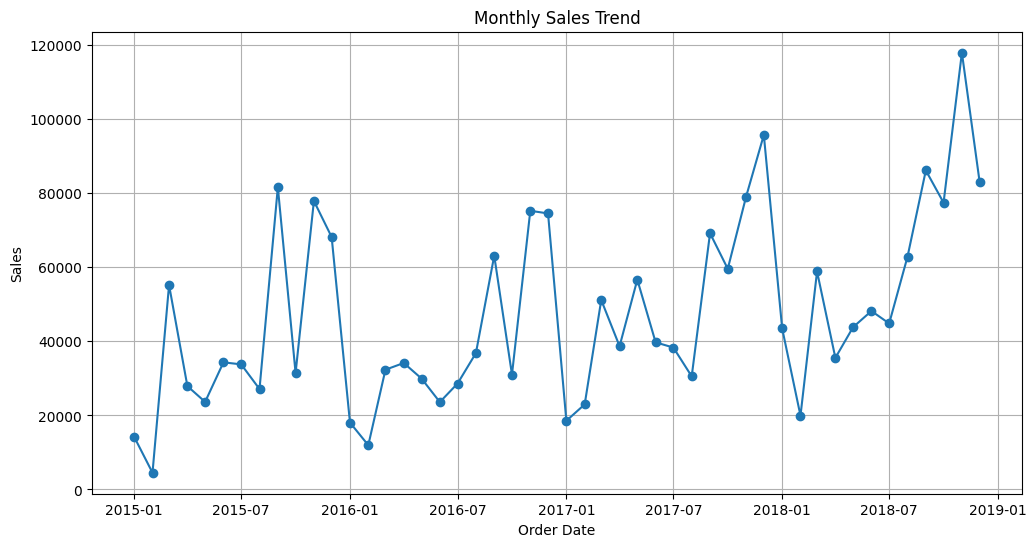

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales['Order Date'],
         monthly_sales['Sales'],
         marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [ ]:
monthly_sales['Month_Number'] = range(len(monthly_sales))

In [ ]:
monthly_sales.head()

,Order Date,Sales,Month,Month_Number
0,2015-01-01,14205.707,0,0
1,2015-02-01,4519.892,1,1
2,2015-03-01,55205.797,2,2
3,2015-04-01,27906.855,3,3
4,2015-05-01,23644.303,4,4


In [ ]:
from sklearn.linear_model import LinearRegression

X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

model = LinearRegression()

model.fit(X,y)

LinearRegression()

In [ ]:
monthly_sales['Predicted Sales'] = model.predict(X)

In [ ]:
monthly_sales.head()

,Order Date,Sales,Month,Month_Number,Predicted Sales
0,2015-01-01,14205.707,0,0,26240.013137
1,2015-02-01,4519.892,1,1,27128.325329
2,2015-03-01,55205.797,2,2,28016.637521
3,2015-04-01,27906.855,3,3,28904.949712
4,2015-05-01,23644.303,4,4,29793.261904


In [ ]:
future_months = pd.DataFrame({
    'Month_Number': range(
        len(monthly_sales),
        len(monthly_sales)+12
    )
})

In [ ]:
future_months['Predicted Sales'] = model.predict(future_months)

In [ ]:
future_months

,Month_Number,Predicted Sales
0,48,68878.998333
1,49,69767.310525
2,50,70655.622716
3,51,71543.934908
4,52,72432.247100
5,53,73320.559291
6,54,74208.871483
7,55,75097.183674
8,56,75985.495866
9,57,76873.808058


In [ ]:
future_dates = pd.date_range(
    start=monthly_sales['Order Date'].max() + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

In [ ]:
future_months['Order Date'] = future_dates

In [ ]:
future_months.head()

,Month_Number,Predicted Sales,Order Date
0,48,68878.998333,2019-01-01
1,49,69767.310525,2019-02-01
2,50,70655.622716,2019-03-01
3,51,71543.934908,2019-04-01
4,52,72432.247100,2019-05-01


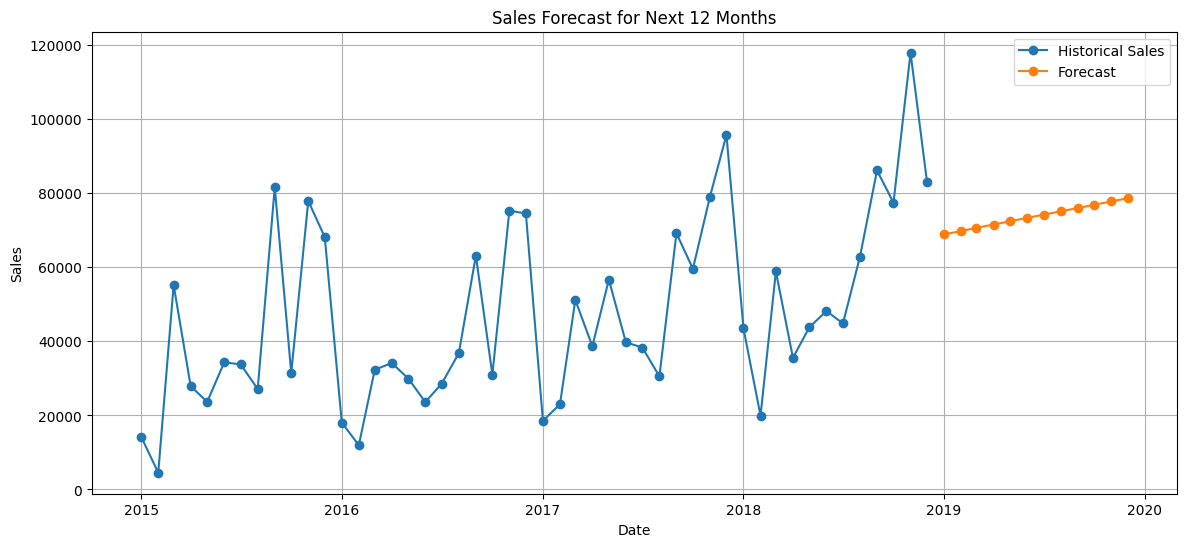

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    label='Historical Sales',
    marker='o'
)

plt.plot(
    future_months['Order Date'],
    future_months['Predicted Sales'],
    label='Forecast',
    marker='o'
)

plt.title("Sales Forecast for Next 12 Months")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
future_months.to_csv(
    "Predicted_Sales.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("Predicted_Sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
future_months.head()

,Month_Number,Predicted Sales,Order Date
0,48,68878.998333,2019-01-01
1,49,69767.310525,2019-02-01
2,50,70655.622716,2019-03-01
3,51,71543.934908,2019-04-01
4,52,72432.247100,2019-05-01


In [ ]:
monthly_sales.to_csv("Historical_Predictions.csv", index=False)

In [ ]:
from google.colab import files
files.download("Historical_Predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>